In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# Importing all required libraries for data loading, cleaning, visualization, and modeling.

In [3]:
df = pd.read_csv("amazonreviews.tsv", sep="\t", header=None, names=["label", "review"])
df.head()

,label,review
0,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,Amazing!: This soundtrack is my favorite music...
4,pos,Excellent Soundtrack: I truly like this soundt...


In [20]:
# Loading the Amazon reviews dataset and displaying basic information.

In [4]:
print("Dataset shape:", df.shape)
print("\nLabel distribution:\n", df['label'].value_counts())
df.info()

Dataset shape: (10001, 2)

Label distribution:
 label
neg      5097
pos      4903
label       1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10001 non-null  object
 1   review  10001 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [22]:
# Performing exploratory data analysis: sentiment counts & word frequency patterns.

In [5]:
df = df.drop_duplicates()
df = df.dropna(subset=["review"])
df = df.reset_index(drop=True)
df.shape

(10001, 2)

In [21]:
# Removing duplicates, handling missing values, and cleaning the text.

In [6]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      
    text = re.sub(r"[^a-zA-Z ]", " ", text)          
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [stemmer.stem(w) for w in words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)
df.head()

,label,review,clean_review
0,label,review,review
1,pos,Stuning even for the non-gamer: This sound tra...,stune even non gamer sound track beauti paint ...
2,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anyth read lot review say...
3,pos,Amazing!: This soundtrack is my favorite music...,amaz soundtrack favorit music time hand intens...
4,pos,Excellent Soundtrack: I truly like this soundt...,excel soundtrack truli like soundtrack enjoy v...


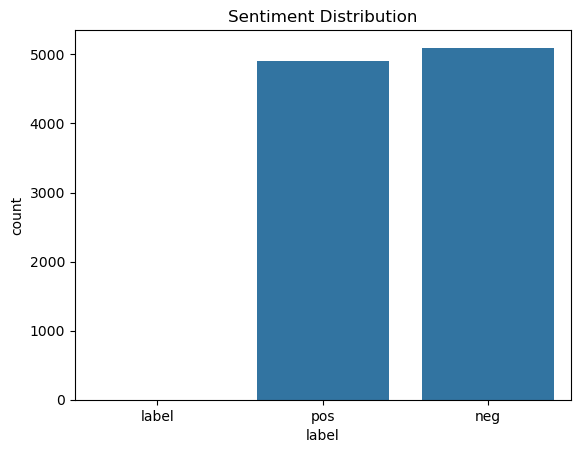

In [7]:
sns.countplot(x=df["label"])
plt.title("Sentiment Distribution")
plt.show()

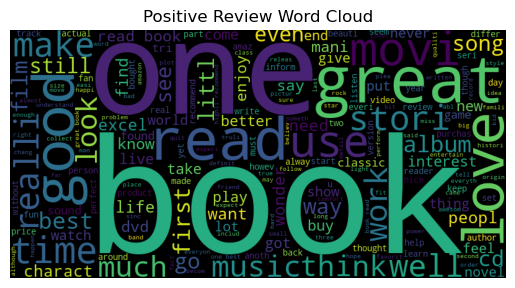

In [8]:
pos_text = " ".join(df[df["label"] == "pos"]["clean_review"])
wc_pos = WordCloud(width=800, height=400).generate(pos_text)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

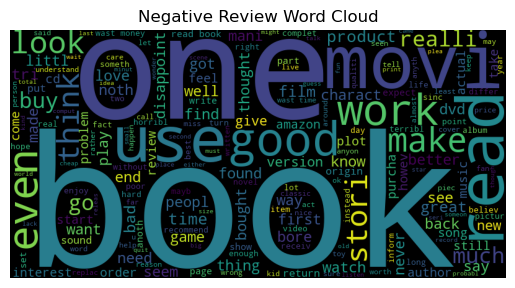

In [9]:
neg_text = " ".join(df[df["label"] == "neg"]["clean_review"])
wc_neg = WordCloud(width=800, height=400).generate(neg_text)
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

In [10]:
df = df[df['label'].isin(['pos', 'neg'])]
X = df["clean_review"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Splitting the dataset into training and testing sets.

In [11]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [23]:
# Converting text reviews into numerical features using TF-IDF vectorization.

In [12]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
lr_grid.fit(X_train_tfidf, y_train)
print("Best Parameters for Logistic Regression:", lr_grid.best_params_)
print("Best Accuracy:", lr_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Accuracy: 0.8564999999999999


In [13]:
best_lr = lr_grid.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_tfidf)
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print("Tuned Classification Report:\n", classification_report(y_test, y_pred_lr_tuned))

Tuned Logistic Regression Accuracy: 0.861
Tuned Classification Report:
               precision    recall  f1-score   support

         neg       0.87      0.86      0.87      1037
         pos       0.85      0.86      0.86       963

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [14]:
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_tfidf, y_train)
y_pred_lr = logreg.predict(X_test_tfidf)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label="pos"))
print("Recall:", recall_score(y_test, y_pred_lr, pos_label="pos"))
print("F1 Score:", f1_score(y_test, y_pred_lr, pos_label="pos"))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8595
Precision: 0.8574423480083857
Recall: 0.8494288681204569
F1 Score: 0.8534167970787689

Classification Report:
               precision    recall  f1-score   support

         neg       0.86      0.87      0.87      1037
         pos       0.86      0.85      0.85       963

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [15]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, pos_label="pos"))
print("Recall:", recall_score(y_test, y_pred_svm, pos_label="pos"))
print("F1 Score:", f1_score(y_test, y_pred_svm, pos_label="pos"))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Results
Accuracy: 0.8585
Precision: 0.8497942386831275
Recall: 0.857736240913811
F1 Score: 0.8537467700258398

Classification Report:
               precision    recall  f1-score   support

         neg       0.87      0.86      0.86      1037
         pos       0.85      0.86      0.85       963

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [ ]:
# Training baseline machine learning models: Logistic Regression and SVM.
# Evaluating the baseline models using accuracy, precision, recall, and F1-score.
# Performing hyperparameter tuning for Logistic Regression using GridSearchCV.

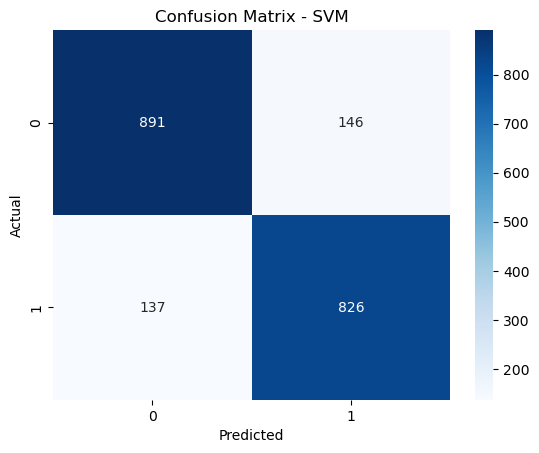

In [16]:
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(logreg, "logreg_model.joblib")
joblib.dump(svm, "svm_model.joblib")
print("Models saved successfully!")

Models saved successfully!


In [18]:
test_review = "This product is amazing and works perfectly!"
cleaned = clean_text(test_review)
vec = tfidf.transform([cleaned])
print("Logistic Regression:", logreg.predict(vec)[0])
print("SVM:", svm.predict(vec)[0])

Logistic Regression: pos
SVM: pos


In [ ]:
# Testing and evaluating the tuned Logistic Regression model.

In [ ]:
# In this assignment, I built an automated Sentiment Analysis System to classify Amazon customer reviews as positive or negative. 
# We began by loading and cleaning the dataset, removing duplicates and preprocessing the review text. 
# After performing exploratory analysis to understand sentiment distribution and frequently occurring words, 
# we transformed the text into numerical features using TF-IDF vectorization. We then trained baseline machine learning models 
# such as Logistic Regression and SVM, and evaluated them using accuracy, precision, recall, and F1-score. 
# Finally, we performed hyperparameter tuning using GridSearchCV to optimize model performance and compared the tuned results. 
# This end-to-end workflow demonstrates a complete and robust sentiment analysis pipeline for real-world e-commerce applications.